In [1]:
!pip install matminer

Defaulting to user installation because normal site-packages is not writeable
  Using cached matminer-0.10.0-py3-none-any.whl.metadata (4.6 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached monty-2026.2.18-py3-none-any.whl.metadata (3.3 kB)
  Using cached pymatgen-2025.10.7-cp313-cp313-win_amd64.whl.metadata (13 kB)
  Using cached bibtexparser-1.4.4-py3-none-any.whl
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
Using cached matminer-0.10.0-py3-none-any.whl (5.3 MB)
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)
Using cached monty-2026.2.18-py3-none-any.whl (52 kB)
Using cached pymatgen-2025.10.7-cp313-cp313-win_amd64.whl (3.6 MB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)

   ---------------------------------------- 0/7 [monty]
   -

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from matminer.datasets import load_dataset

df = load_dataset("matbench_expt_gap")
df.head()

Fetching matbench_expt_gap.json.gz from https://ml.materialsproject.org/projects/matbench_expt_gap.json.gz to C:\Users\lenovo\AppData\Roaming\Python\Python313\site-packages\matminer\datasets\matbench_expt_gap.json.gz


Fetching https://ml.materialsproject.org/projects/matbench_expt_gap.json.gz in MB: 0.038911999999999995MB [00:00, 21.61MB/s]


,composition,gap expt
0,Ag(AuS)2,0.00
1,Ag(W3Br7)2,0.00
2,Ag0.5Ge1Pb1.75S4,1.83
3,Ag0.5Ge1Pb1.75Se4,1.51
4,Ag2BBr,0.00


In [3]:
df.shape

(4604, 2)

In [4]:
df.describe()

,gap expt
count,4604.000000
mean,0.975951
std,1.445034
min,0.000000
25%,0.000000
50%,0.000000
75%,1.812500
max,11.700000


In [5]:
from matminer.featurizers.composition import ElementProperty
from pymatgen.core import Composition

df["composition"] = df["composition"].apply(Composition)

featurizer = ElementProperty.from_preset("magpie")
df_features = featurizer.featurize_dataframe(df, col_id="composition")

C:\Users\lenovo\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
ElementProperty: 100%|█████████████████████████████████████████████████████████████| 4604/4604 [03:40<00:00, 20.91it/s]


In [6]:
df_features.shape

(4604, 134)

In [7]:
df_features.head()

,composition,gap expt,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,"(Ag, Au, S)",0.00,16.0,79.0,63.0,47.400000,25.280000,16.0,65.0,88.0,...,0.0,0.0,0.0,0.0,70.0,225.0,155.0,163.000000,74.400000,70.0
1,"(Ag, W, Br)",0.00,35.0,74.0,39.0,46.714286,15.619048,35.0,51.0,95.0,...,0.0,0.0,0.0,0.0,64.0,229.0,165.0,118.809524,73.079365,64.0
2,"(Ag, Ge, Pb, S)",1.83,16.0,82.0,66.0,36.275862,23.552913,16.0,65.0,88.0,...,0.0,0.0,0.0,0.0,70.0,225.0,155.0,139.482759,76.670630,70.0
3,"(Ag, Ge, Pb, Se)",1.51,32.0,82.0,50.0,46.206897,17.388823,34.0,65.0,89.0,...,0.0,0.0,0.0,0.0,14.0,225.0,211.0,108.586207,104.370987,14.0
4,"(Ag, B, Br)",0.00,5.0,47.0,42.0,33.500000,14.250000,47.0,65.0,95.0,...,0.0,0.0,0.0,0.0,64.0,225.0,161.0,170.000000,55.000000,225.0


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [9]:
X = df_features.drop(columns=["gap expt", "composition"])
y = df_features["gap expt"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [10]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [11]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 0.4425635106768006


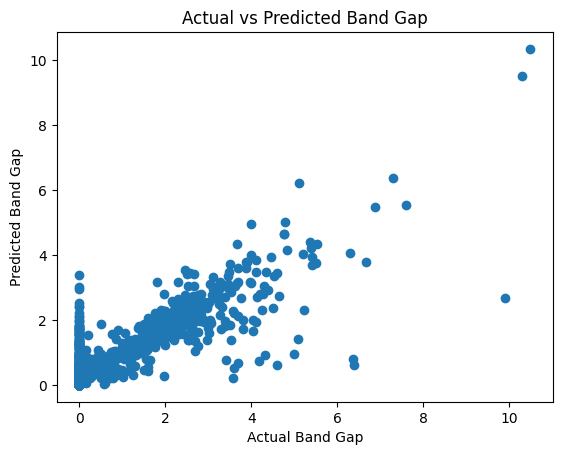

In [12]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Band Gap")
plt.ylabel("Predicted Band Gap")
plt.title("Actual vs Predicted Band Gap")
plt.show()

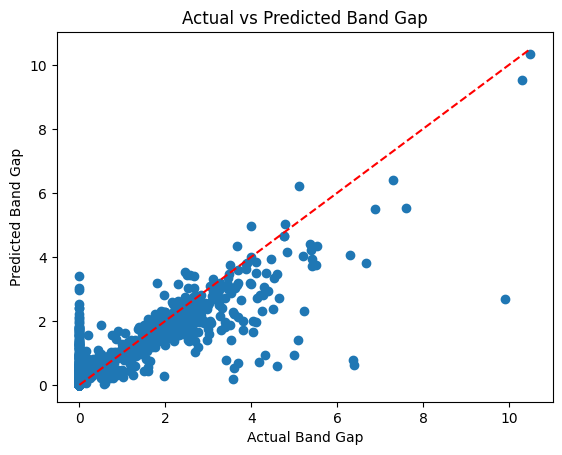

In [13]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Band Gap")
plt.ylabel("Predicted Band Gap")
plt.title("Actual vs Predicted Band Gap")

plt.show()

The model performs well for low band gap materials, 
while higher band gap values show increased prediction error and scatter.